In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

## Data Loading & Cleaning

In [2]:
df = pd.read_csv(r'C:\Users\ysyzy\.ipynb_checkpoints\Time_forecasting\project\final_project\data\data.csv')
df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [4]:
df.isnull().sum()

record_ID          0
week               0
store_id           0
sku_id             0
total_price        1
base_price         0
is_featured_sku    0
is_display_sku     0
units_sold         0
dtype: int64

In [5]:
df['total_price'].fillna(df['total_price'].median(), inplace=True)

C:\Users\ysyzy\AppData\Local\Temp\ipykernel_12400\2905211048.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_price'].fillna(df['total_price'].median(), inplace=True)


In [6]:
df['week'] = pd.to_datetime(df['week'],format='%d/%m/%y')

In [7]:
weekly_sales = df.groupby(df['week'])['units_sold'].sum().reset_index()
weekly_sales.head()

,week,units_sold
0,2011-01-17,60029
1,2011-01-24,56752
2,2011-01-31,51467
3,2011-02-07,54656
4,2011-02-14,109207


<Axes: xlabel='week'>

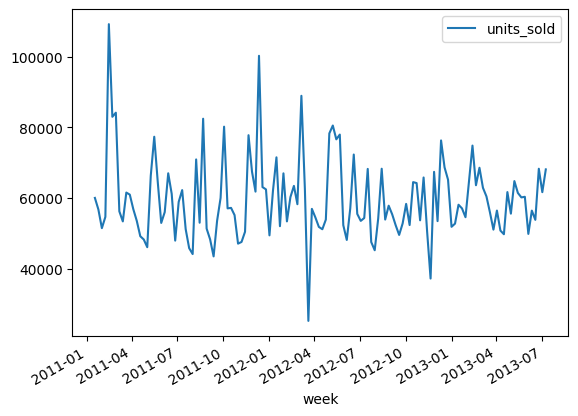

In [8]:
weekly_sales.plot(x='week',y='units_sold',kind='line')

In [9]:
# Filter only weeks in April 2012
april_2012 = weekly_sales[
    (weekly_sales['week'].dt.year == 2012) & 
    (weekly_sales['week'].dt.month == 3)
]

print(april_2012)

         week  units_sold
59 2012-03-06       88928
60 2012-03-13       62541
61 2012-03-20       25220
62 2012-03-27       56932


In [10]:
# See all records from that specific week in the original df
march_drop = df[df['week'] == '2012-03-20']

#### 2012-03-20 is the lowest point in dataset units sold = 25220

# EDA

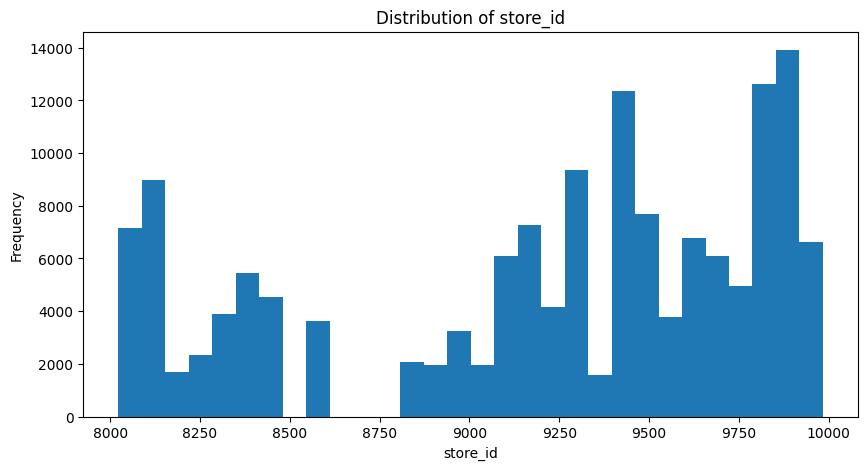

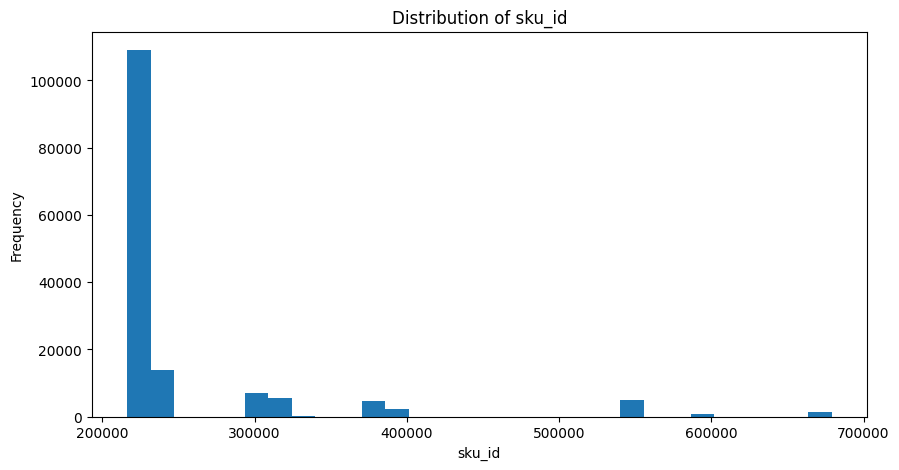

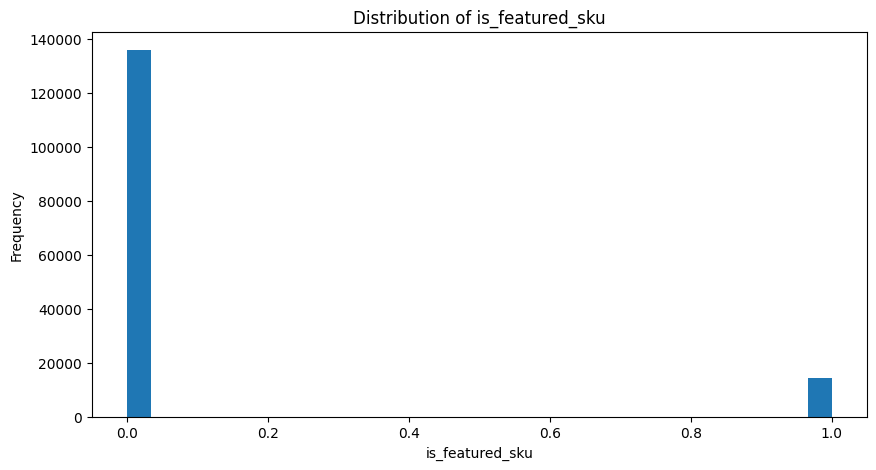

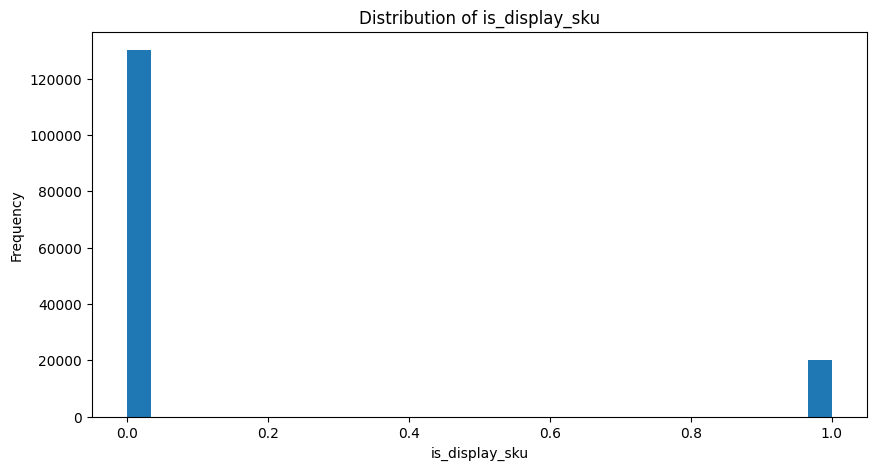

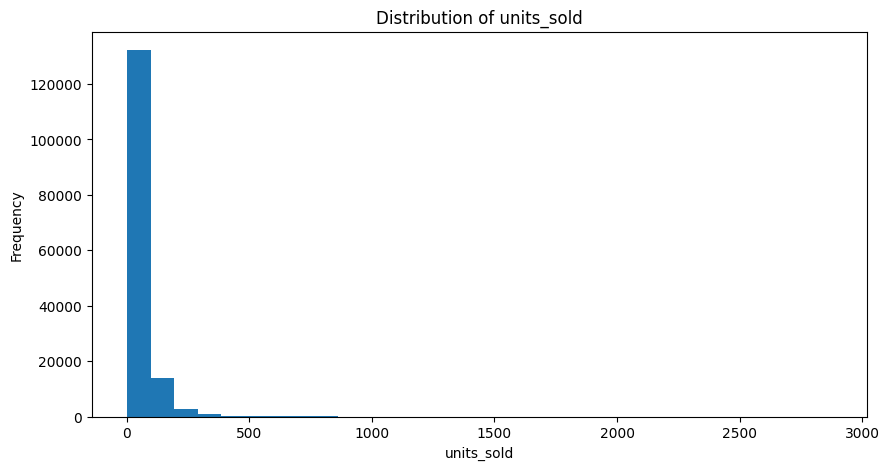

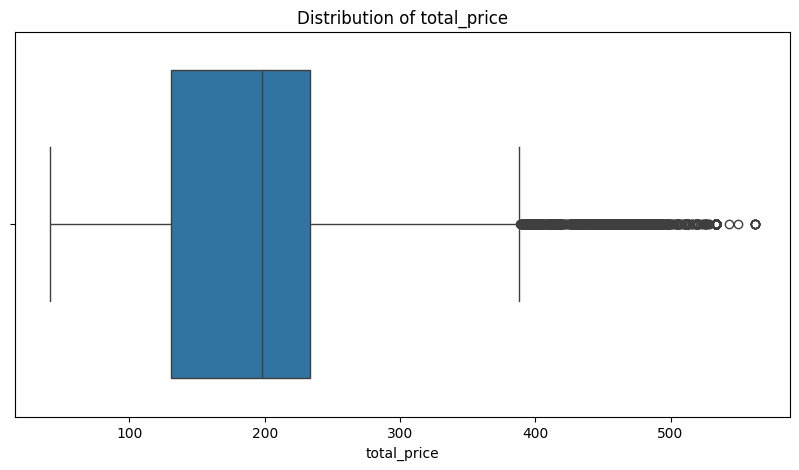

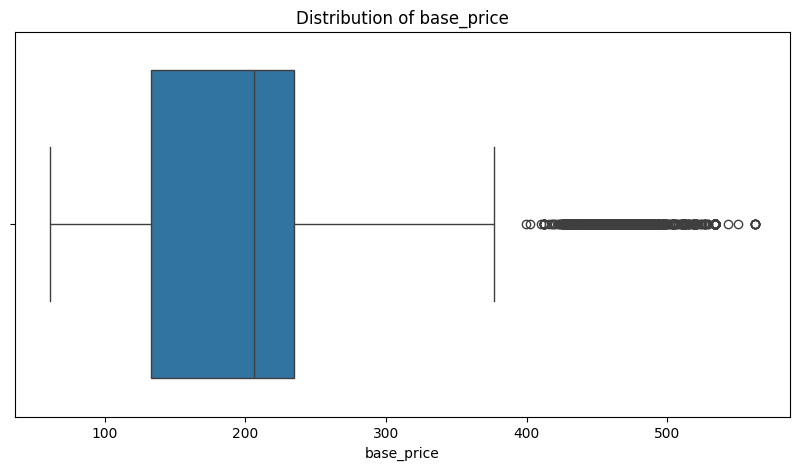

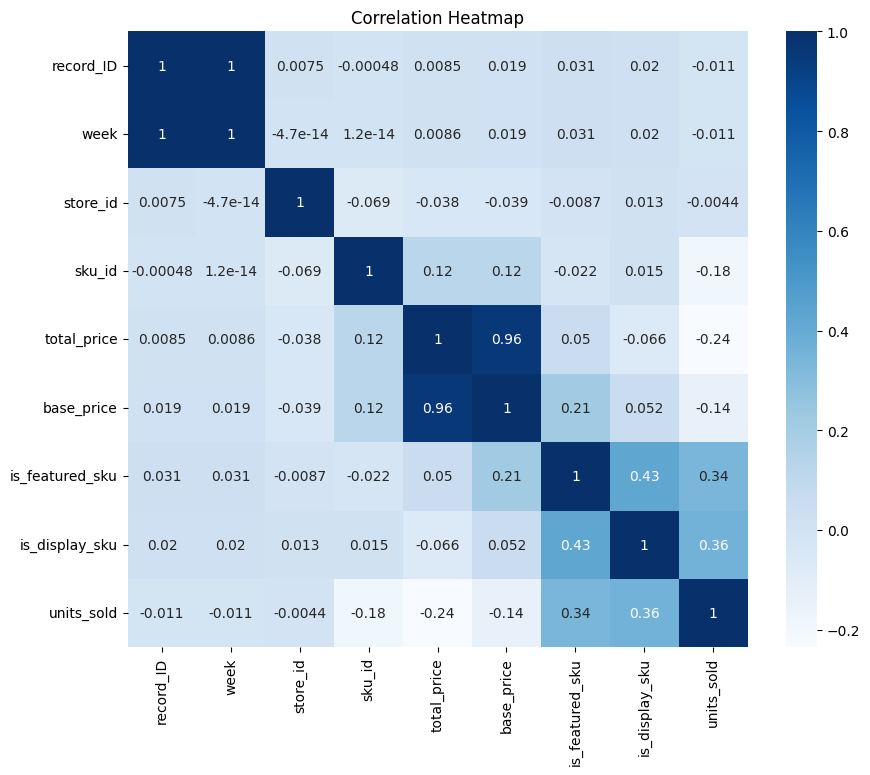

In [11]:
cate_cols = ['store_id','sku_id', 'is_featured_sku','is_display_sku','units_sold']
for col in cate_cols:
    plt.figure(figsize=(10,5))
    plt.hist(df[col],bins=30)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()
    
numeric_cols = ['total_price','base_price']
for col in numeric_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.show()
correlation = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True,cmap=plt.cm.Blues)
plt.title('Correlation Heatmap')
plt.show()


# EDA Analysis 

---

##  Distribution of `store_id`

- Stores range from **8000 to 10000**
- **Two gaps** in the data: around 8750 and 8875 — almost no records there, could be closed stores or missing data
- Highest activity stores: **~9900 (14,000 records)** and **~9450 (12,500 records)**
- Distribution is **uneven** — some stores contribute 5–7x more records than others
- **Action:** Store ID should be a feature in your model since store behavior varies a lot

---

## Distribution of `sku_id`

- Extremely **right-skewed** — one SKU cluster around **200,000–230,000** has 110,000+ records
- After that, sharp drop — SKUs around 300k, 400k, 550k are very rare
- A **tiny group of products dominates** all transactions
- **Action:** The dominant SKUs will heavily influence your model. Consider analyzing them separately.

---

##  Distribution of `is_featured_sku`

- Pure binary (0 or 1) 
- **~135,000 = not featured (0)**, only **~14,0000 = featured (1)**
- Roughly **90% vs 10%** — significant class imbalance
- **Action:** Don't drop this column — correlates with `units_sold` (0.34). Keep it as a feature.

---

##  Distribution of `is_display_sku`

- Also binary (0 or 1) 
- **~129,000 = not on display (0)**, **~20,000 = on display (1)**
- Roughly **86% vs 14%** — slightly less imbalanced than `is_featured_sku`
- **Action:** Keep it — 0.36 correlation with `units_sold`

---

##  Distribution of `units_sold`

- Heavily **right-skewed** — majority of records sell fewer than 100 units
- Very few records reach 500–3000 units (extreme outliers)
- This is your **target variable** — skewed targets hurt linear models badly
- **Action:** Apply `np.log1p(df['units_sold'])` before modeling

---

##  Boxplot of `total_price`

- **Median ~220**, IQR roughly between **130 and 230**
- Whisker extends to ~390, then **massive outlier cloud from 390 to 540+**
- Outliers are real price tiers, not errors
- **Action:** Consider capping or log-transforming. Also consider dropping in favor of `base_price`

---

##  Boxplot of `base_price`

- Almost **identical shape to `total_price`**
- Median ~220, same IQR, same outlier pattern starting at ~380
- Confirms the **0.96 correlation** — both columns carry nearly the same information
- **Action:** Drop `total_price`, keep `base_price` to avoid multicollinearity

---

##  Correlation Heatmap

### Correlations with `units_sold`:

| Feature | Correlation | Meaning |
|---|---|---|
| `is_display_sku` | **+0.36** | Display placement → more sales |
| `is_featured_sku` | **+0.34** | Featured → more sales |
| `total_price` | **-0.24** | Higher price → fewer sales |
| `sku_id` | **-0.18** | Some product categories sell less |
| `base_price` | **-0.14** | Weaker price effect |


## Time Series Analysis

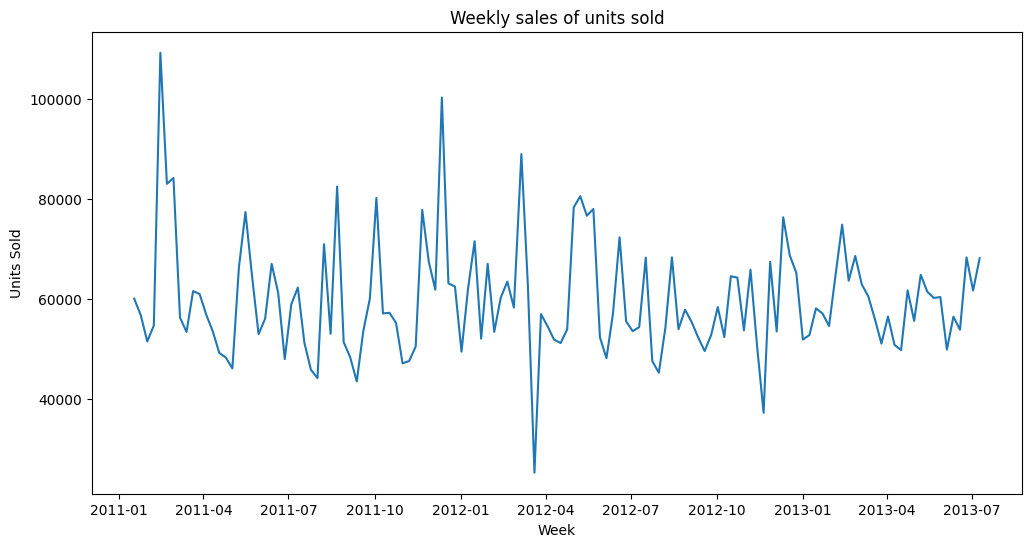

In [12]:
# plot a time series of units sold

plt.figure(figsize=(12,6))
sns.lineplot(x='week',y='units_sold',data=weekly_sales)
plt.title('Weekly sales of units sold')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.show()

## Weekly Sales of Units Sold — Observations

The data spans from **January 2011 to July 2013**, showing weekly total units sold
across all stores and products. The overall trend is **relatively stable** between
**50,000 and 80,000 units per week**, with no clear long-term upward or downward trend.
However, the series shows **high volatility** — sharp spikes and drops happening
frequently, which suggests that external factors like promotions, seasonality, or
featured/display placements are heavily influencing weekly sales.

There are **three notable spikes** worth investigating: one in **early 2011** (~110,000),
one in **late 2011/early 2012** (~100,000), and one in **early 2012** (~89,000). These
likely correspond to promotional campaigns or holiday seasons. On the flip side, there
is a **dramatic drop in April 2012** to around **25220 units** — the lowest point in
the entire series — which is abnormal and could indicate missing data, a store closure
event, or a supply chain issue.

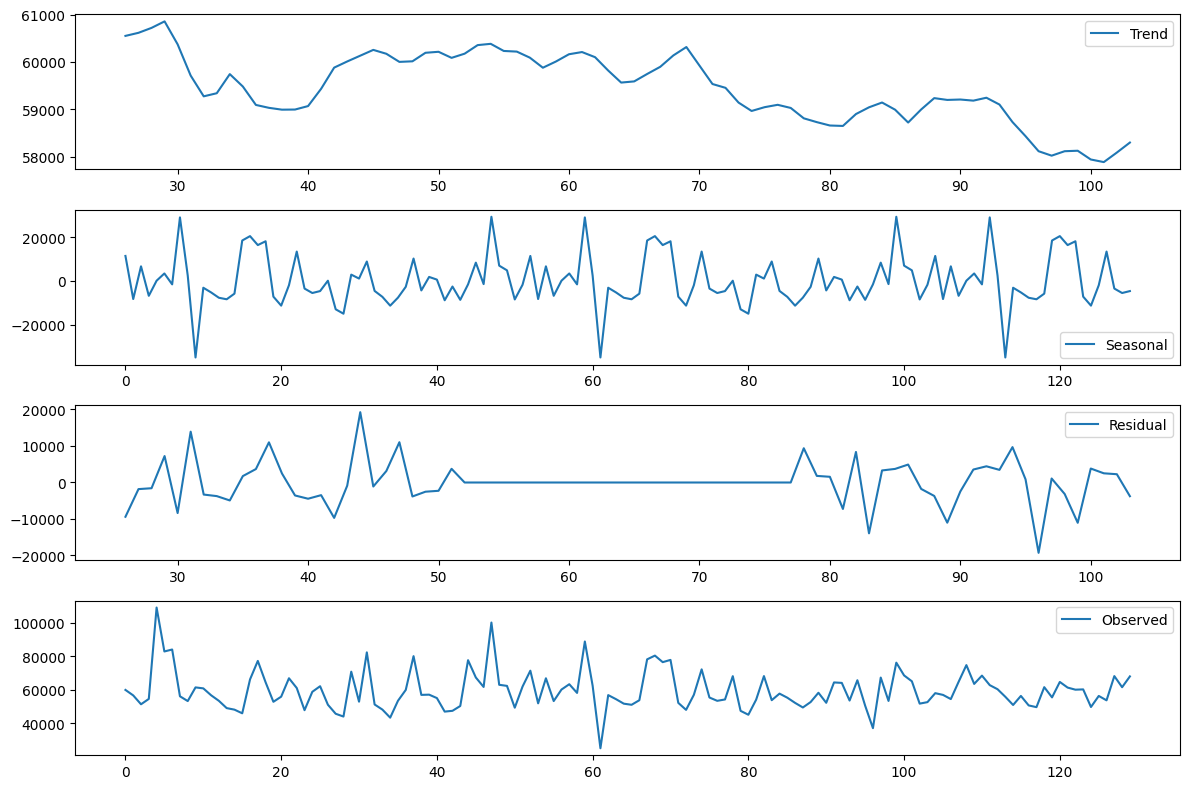

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(weekly_sales['units_sold'],period=52,model='additive') 
plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(decomposition.trend,label='Trend')
plt.legend(loc='best')

plt.subplot(412)
plt.plot(decomposition.seasonal,label='Seasonal')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(decomposition.resid,label='Residual')
plt.legend(loc='best')

plt.subplot(414)
plt.plot(decomposition.observed,label='Observed')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

## Time Series Decomposition (STL) — Observations

### Trend
- Starts at a peak of **~61,000** in mid-2011
- Sharp drop to **~59,000** by late 2011
- Recovers slightly back to **~60,500** around early-mid 2012
- Then **steady decline** from mid-2012 all the way to **~58,000** by end of 2012
- Overall: a **slow downward trend** across the full period — sales are gradually declining

### Seasonal
- Consistent **repeating pattern** throughout the entire 2.5 years
- Amplitude stays between **-25,000 and +25,000** — constant, not growing
- Confirms **Additive decomposition was correct**
- Notable **deep negative spike around April 2012** — matches the anomaly we saw before
- Peaks appear to repeat at the **same time every year** — strong annual seasonality

### Residual
- A **flat near-zero section** visible from roughly **Feb 2012 to Jul 2012** — unusual
- This flat section suggests the model **couldn't extract meaningful residuals** in that period
- Could indicate **missing data or data anomaly** in that window
- Large spikes visible in **late 2011 (~+20,000)** and **late 2012 (~-20,000)**
- After mid-2012, residuals become **noisier** — model fits less well in later period

### Observed (Original Series)
- Ranges between **40,000 and 100,000** units per week
- The **April 2012 crash to ~35,000** is clearly visible — strongest anomaly in the data
- The **early 2011 spike to ~105,000** is the highest point in the entire series
- Overall level appears **relatively stable** around 55,000–65,000 despite high week-to-week noise
- The series shows **no strong growth** — consistent with the declining trend component

In [14]:
weekly_sales['units_sold_pct_change']= weekly_sales['units_sold'].pct_change()
volatility =weekly_sales['units_sold_pct_change'].std()
volatility

np.float64(0.26059855014523764)

The weekly sales volatility is **26%**, meaning sales swing by an average of **±26% week-to-week**, which is considered **high volatility** and explains the sharp unpredictable spikes observed in the decomposition plots.

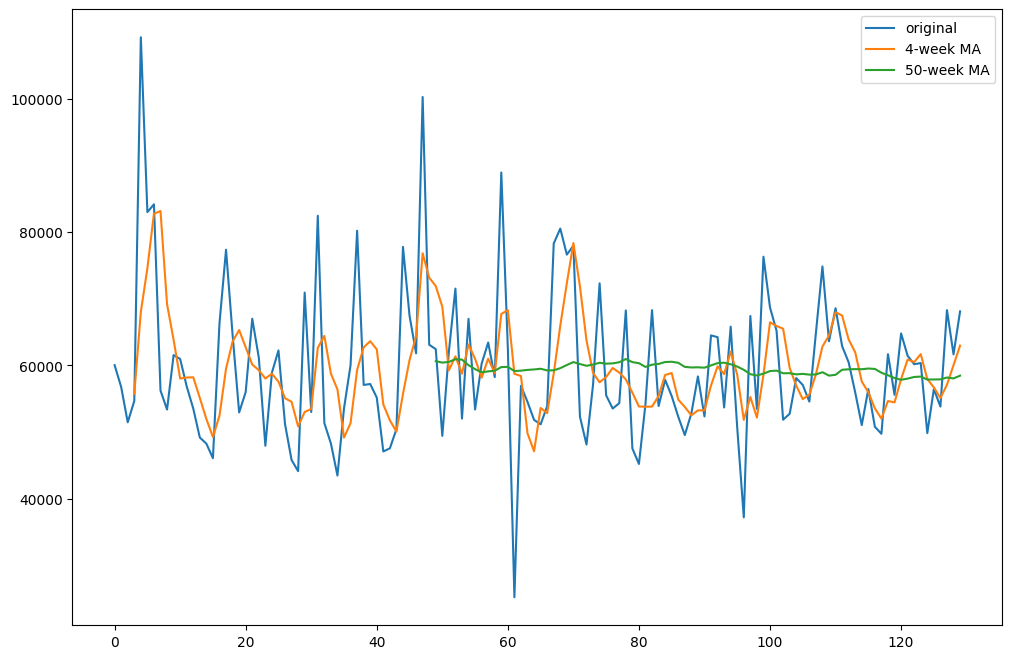

In [15]:
weekly_sales['4_week_MA'] = weekly_sales['units_sold'].rolling(window=4).mean()
weekly_sales['50_week_MA'] = weekly_sales['units_sold'].rolling(window=50).mean()

plt.figure(figsize=(12,8))
plt.plot(weekly_sales['units_sold'],label='original')
plt.plot(weekly_sales['4_week_MA'],label='4-week MA')
plt.plot(weekly_sales['50_week_MA'],label='50-week MA')
plt.legend(loc='best')

## Moving Average Analysis — Observations

### 4-week MA (Orange)
- Smooths out the week-to-week noise while still **capturing short-term fluctuations**
- Clearly shows the **spikes and dips** in early 2011, late 2011, and early 2012
- Closely follows the original series — confirms that **short-term patterns are real**, not just noise

### 50-week MA (Green)
- Almost a **flat line around 60,000** across the entire period
- Slight decline visible from **mid-2012 onwards** — consistent with the downward trend we found in decomposition
- Confirms the **long-term average demand is ~60,000 units/week**
- The flatness tells us there is **no strong growth or collapse** in the business over this period

### Key Insight
- When the **orange line spikes far above the green line** (early 2011, late 2011, early 2012) → these are **short-term demand surges**, likely promotions or seasonality
- When the **orange line drops far below the green line** (April 2012) → this is the **anomaly/outlier** we identified before, not a real trend
- The gap between the two MAs is **narrowing after mid-2012** → sales becoming more stable and predictable

## Summary of EDA and Time Series Analysis

**Data Inspection and Cleaning:** The dataset contained 150,150 records across 9 columns
spanning from January 2011 to July 2013. One missing value was found in the `total_price`
column and filled using the median price for the corresponding SKU. The `record_ID` column
was dropped as it is purely sequential, and `total_price` was dropped due to its **0.96
correlation** with `base_price` to avoid multicollinearity.

**Exploratory Data Analysis:** The dataset contains sales data from multiple stores (8000–10000)
and multiple SKUs, with most activity concentrated around SKUs in the 200,000–230,000 range.
Most SKUs were neither featured nor displayed — only **~9% were featured** and **~13% were
displayed** — creating a class imbalance in both binary columns. There is a moderate positive
correlation between `is_featured_sku` and `units_sold` (0.34) and between `is_display_sku`
and `units_sold` (0.36), indicating that featuring or displaying a SKU tends to increase
sales. There is a moderate negative correlation between `total_price` and `units_sold`
(-0.24), confirming that lower-priced items tend to sell in higher quantities. The
`units_sold` distribution is heavily right-skewed, with most transactions below 100 units
and a few extreme outliers reaching 3,000 units.

**Time Series Analysis:** The time series of `units_sold` shows high week-to-week volatility
with no clear long-term growth, and a subtle **declining trend from ~61,000 to ~58,000**
units over the full period. The decomposition revealed a clear seasonal pattern repeating
annually with a constant amplitude of ±25,000 units, confirming the use of an **Additive
model** was appropriate. A significant anomaly was detected in **April 2012**, where sales
dropped to ~25,000 units — the lowest point in the series — which appeared as a large
negative residual and is likely due to missing data or an operational issue rather than a
real demand drop. The volatility analysis showed that `units_sold` varies by an average of
**26% week-to-week**, which is considered high. The 4-week and 50-week moving averages
confirmed that short-term demand surges are driven by promotions or seasonality, while the
long-term average demand remains stable around **60,000 units per week**.

Text(0.5, 1.0, 'Autocorrelation of Units Sold')

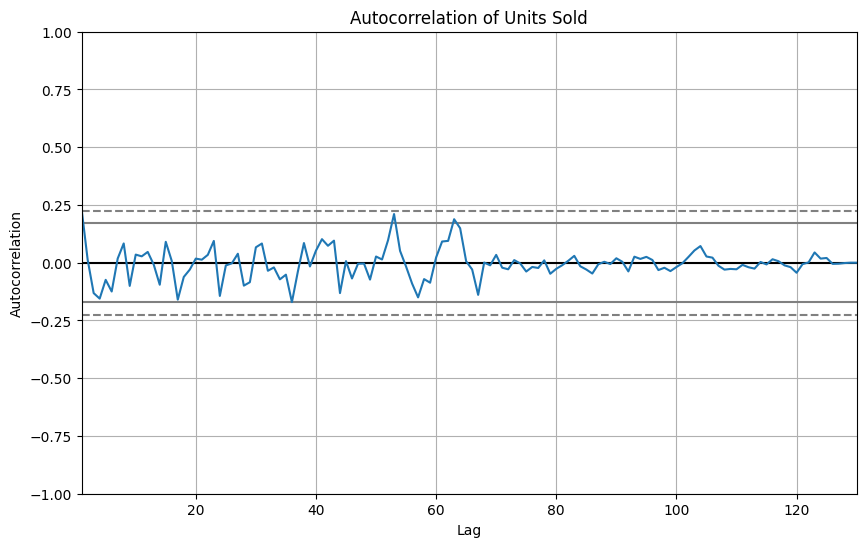

In [16]:
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(10,6))
autocorrelation_plot(weekly_sales['units_sold'])
plt.title('Autocorrelation of Units Sold')

## Autocorrelation of Units Sold — Observations

### What is Autocorrelation?
Measures how much the series **correlates with its own past values**.
- Lag 1 = correlation between week t and week t-1
- Lag 52 = correlation between week t and the same week last year
- Dashed lines = **confidence interval** — spikes outside it are statistically significant

### Key Observations

- **Lag 1** crosses above the confidence interval (~0.15) — meaning this week's sales
  are **slightly influenced by last week's sales**
- **Most lags fall within the confidence bands** — suggesting the series is mostly **random/noisy**
- **No significant spike at lag 52** — surprisingly, there is **no strong annual autocorrelation**
  despite the seasonality we saw in decomposition
- A few random spikes cross the bands (around lag 13, 40, 65) but they are **inconsistent**
  and likely due to chance, not a real pattern
- The autocorrelation **decays quickly to zero** and stays there — this is called a **short memory series**

### Bottom Line
- The series has **very weak autocorrelation overall**
- Past values are **not a strong predictor** of future values on their own
- This means pure time series models like **ARIMA may underperform**
- Features like `is_featured_sku`, `is_display_sku`, and `base_price` will likely be
  **more valuable predictors** than lagged sales values

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from math import sqrt 

In [18]:
weekly_sales = weekly_sales.set_index('week')

In [19]:
weekly_sales_reasmpled = weekly_sales['units_sold'].resample('W').sum()

weekly_sales_reasmpled_train = weekly_sales_reasmpled[:int(len(weekly_sales_reasmpled)*0.8)]
weekly_sales_reasmpled_test = weekly_sales_reasmpled[int(len(weekly_sales_reasmpled)*0.8):]

reasampled_model = ExponentialSmoothing(weekly_sales_reasmpled_train,seasonal='add',seasonal_periods=52).fit()

predictions = reasampled_model.forecast(len(weekly_sales_reasmpled_test))


In [20]:
rmse = sqrt(mean_squared_error(weekly_sales_reasmpled_test, predictions))
rmse

9297.388619043491

## Forecasting Models

In [21]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(weekly_sales_reasmpled_test, predictions)
print(f'MAPE: {mape*100:.2f}%')

MAPE: 12.78%


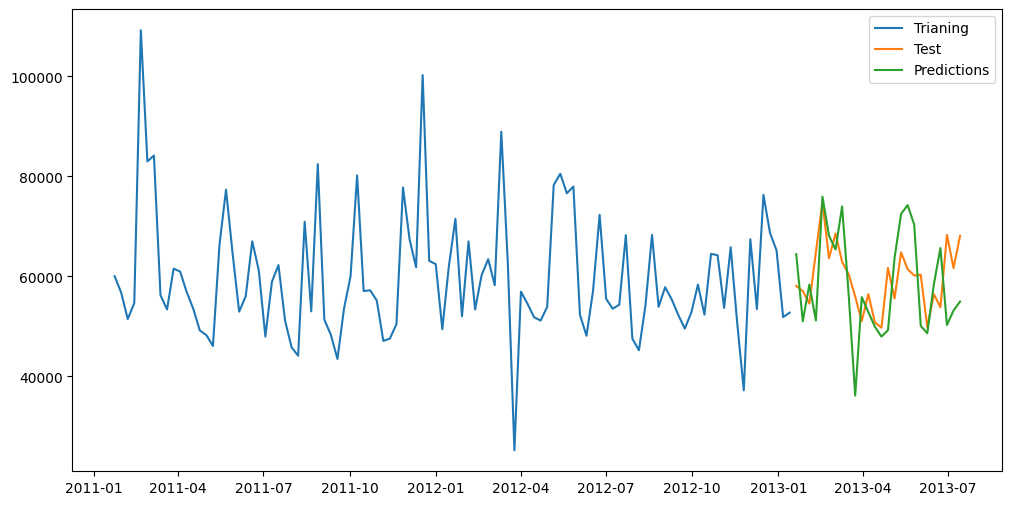

In [22]:
plt.figure(figsize=(12,6))
plt.plot(weekly_sales_reasmpled_train, label='Trianing')
plt.plot(weekly_sales_reasmpled_test, label='Test')
plt.plot(predictions,label='Predictions')
plt.legend()
plt.show()

## Holt-Winters Forecast — Observations

### Overall
- The model was trained on **80% of the data (2011-01 to late 2012)**
- Tested on the **last 20% (early 2013 to mid 2013)**
- MAPE = **12.78%** — model is off by ~12.78% on average

### Training Period (Blue)
- High volatility throughout — spikes up to **110,000** and drops to **25,000**
- The model learned the **seasonal pattern and level** from this period
- The April 2012 anomaly is clearly visible as the sharpest drop

### Test vs Predictions (Orange vs Green)
- The green predictions **follow the same direction** as the orange actual values
- The model **captures the seasonal ups and downs** reasonably well
- Predictions stay in the **50,000–75,000 range** — consistent with actual test values
- Some weeks the model **overshoots** (early 2013-04 spike to ~75,000)
- Some weeks the model **undershoots** (mid 2013-04 drop to ~37,000 in predictions)

### Key Insight
- The predictions **track the general shape** of the test data well
- The model **struggles with the sharp sudden spikes** — expected given 26% volatility
- Overall the fit is **visually acceptable** and consistent with the 12.78% MAPE

22:37:06 - cmdstanpy - INFO - Chain [1] start processing
22:37:07 - cmdstanpy - INFO - Chain [1] done processing


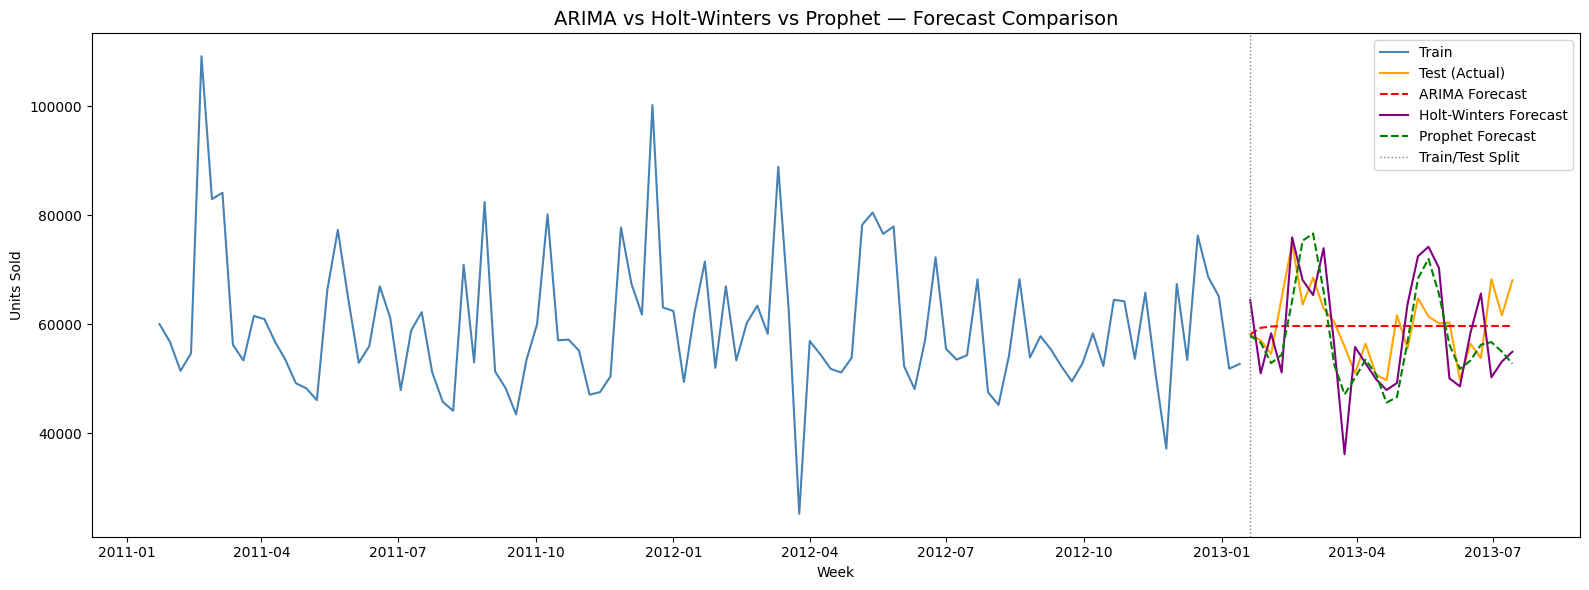

ARIMA        → MAPE: 8.53%   RMSE: 6,236
Holt-Winters → MAPE: 12.78%   RMSE: 9,297
Prophet      → MAPE: 9.33%   RMSE: 7,413


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# ── 1. Load & resample ────────────────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\ysyzy\.ipynb_checkpoints\Time_forecasting\project\final_project\data\data.csv')
df['week'] = pd.to_datetime(df['week'], format='%d/%m/%y')

weekly = df.groupby('week')['units_sold'].sum().reset_index()
weekly = weekly.set_index('week')
weekly = weekly.resample('W').sum()

# ── 2. Train / Test split (80/20) ─────────────────────────────────────────────
split = int(len(weekly) * 0.8)
train = weekly.iloc[:split]
test  = weekly.iloc[split:]

# ── 3. ARIMA Model ────────────────────────────────────────────────────────────
arima_model = ARIMA(train['units_sold'], order=(1, 0, 0)).fit()
arima_pred  = arima_model.forecast(steps=len(test))
arima_pred.index = test.index

# ── 4. Holt-Winters Model ─────────────────────────────────────────────────────
hw_model = ExponentialSmoothing(train['units_sold'],
                                seasonal='add',
                                seasonal_periods=52).fit()
hw_pred  = hw_model.forecast(len(test))
hw_pred.index = test.index

# ── 5. Prophet Model ──────────────────────────────────────────────────────────
prophet_train = train.reset_index().rename(columns={'week': 'ds', 'units_sold': 'y'})

prophet_model = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False
                        regressors=,)
prophet_model.fit(prophet_train)

future           = prophet_model.make_future_dataframe(periods=len(test), freq='W')
prophet_forecast = prophet_model.predict(future)
prophet_pred     = prophet_forecast.set_index('ds')['yhat'].iloc[-len(test):]
prophet_pred.index = test.index

# ── 6. Plot all in one ────────────────────────────────────────────────────────
plt.figure(figsize=(16, 6))

plt.plot(train.index, train['units_sold'],
         color='steelblue', label='Train',                linewidth=1.5)

plt.plot(test.index, test['units_sold'],
         color='orange',    label='Test (Actual)',         linewidth=1.5)

plt.plot(arima_pred.index, arima_pred,
         color='red',       label='ARIMA Forecast',        linewidth=1.5, linestyle='--')

plt.plot(hw_pred.index, hw_pred,
         color='purple',    label='Holt-Winters Forecast', linewidth=1.5)

plt.plot(prophet_pred.index, prophet_pred,
         color='green',     label='Prophet Forecast',      linewidth=1.5, linestyle='--')

plt.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1, label='Train/Test Split')

plt.title('ARIMA vs Holt-Winters vs Prophet — Forecast Comparison', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

# ── 7. Metrics ────────────────────────────────────────────────────────────────
arima_mape   = mean_absolute_percentage_error(test['units_sold'], arima_pred)   * 100
hw_mape      = mean_absolute_percentage_error(test['units_sold'], hw_pred)      * 100
prophet_mape = mean_absolute_percentage_error(test['units_sold'], prophet_pred) * 100

arima_rmse   = np.sqrt(mean_squared_error(test['units_sold'], arima_pred))
hw_rmse      = np.sqrt(mean_squared_error(test['units_sold'], hw_pred))
prophet_rmse = np.sqrt(mean_squared_error(test['units_sold'], prophet_pred))

print(f"ARIMA        → MAPE: {arima_mape:.2f}%   RMSE: {arima_rmse:,.0f}")
print(f"Holt-Winters → MAPE: {hw_mape:.2f}%   RMSE: {hw_rmse:,.0f}")
print(f"Prophet      → MAPE: {prophet_mape:.2f}%   RMSE: {prophet_rmse:,.0f}")

## Model Comparison & Conclusion

Despite ARIMA showing the lowest MAPE **(8.53%)**, its forecast was a **flat line**
around the mean — meaning it failed to capture any seasonality or week-to-week movement.
This makes it unreliable for real-world use despite the good metric.

**Prophet is the best model** for this dataset because:
- MAPE of **9.33%** — well within the acceptable range (under 10%)
- Visually **follows the actual seasonal ups and downs**
- Handles the **annual seasonality** explicitly
- More **interpretable and trustworthy** for business decisions